# How each series was derived

This notebook explains the flat files in [`deliverables/`](../deliverables):
consolidated **general-government** fiscal series for the **United Kingdom,
France and Germany** — expenditure by COFOG function, revenue by ESA type, the
balance ledger, and the reconciliation to the IMF *World Economic Outlook*
general-government aggregates.

It is meant to be read top to bottom and re-run after any rebuild: every number
below is computed from the CSVs at run time, so nothing here can go stale
relative to the data.

**Two rules govern every series, and they explain most of the design:**

1. **Maximise length subject to transparency and conceptual integrity.** A
   series is extended backwards or forwards only where an official source can
   carry it, and every extension records the source, the measured coverage and
   a quality grade.
2. **Decompose, never force.** No line is ever scaled, tilted or adjusted to
   make an aggregate match. Where our lines and the WEO disagree, the
   disagreement is published as a residual instead of being allocated away.

The full specification is `COFOG_KICKOFF.md` in the repository root; the
decision log is `DECISIONS.md`. This notebook is the readable path into both.

In [1]:
from pathlib import Path

import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# Works whether the notebook is run from notebooks/ or from the repo root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"


def load(name):
    return pd.read_csv(DELIV / f"{name}.csv")


expenditure = load("expenditure_cofog")
revenue = load("revenue_esa")
ledger = load("balance_ledger")
levels = load("weo_levels_bridge")
recon = load("weo_reconciliation")
catalogue = load("series_catalogue")
dictionary = load("data_dictionary")

pd.DataFrame(
    [(n, len(df), df.shape[1]) for n, df in [
        ("expenditure_cofog", expenditure), ("revenue_esa", revenue),
        ("balance_ledger", ledger), ("weo_levels_bridge", levels),
        ("weo_reconciliation", recon), ("series_catalogue", catalogue),
        ("data_dictionary", dictionary)]],
    columns=["file", "rows", "columns"]).set_index("file")

,rows,columns
file,,
expenditure_cofog,3020,26
revenue_esa,2660,26
balance_ledger,196,22
weo_levels_bridge,398,32
weo_reconciliation,5995,14
series_catalogue,72,23
data_dictionary,146,3


## 1. What is in the files

`expenditure_cofog.csv` and `revenue_esa.csv` are the two trees. One row is one
country × variant × line × year. Each country has

* **12 COFOG expenditure lines** — `GF01`–`GF10` at COFOG Level I, plus the
  interest split `GF01_7` (COFOG 01.7, public debt transactions) and
  `GF01_X` = `GF01 − GF01_7`, general public services excluding interest —
  and `TE`, total expenditure;
* **10 ESA revenue lines** — `R01`–`R10`, from VAT through to other transfers
  receivable — and `TR`, total revenue.

That is the 66 line series of the specification (3 countries × 22 lines), plus
the two totals per country.

In [2]:
lines_ = pd.concat([expenditure, revenue])
overview = (lines_.groupby(["iso3", "line_code"])
            .agg(label=("line_label", "first"),
                 first_year=("year", "min"),
                 last_year=("year", "max"),
                 rows=("year", "size")))
overview.loc["GBR"].head(24)

,label,first_year,last_year,rows
line_code,,,,
GF01,General public services,1995,2027,63
GF01_7,Public debt transactions (interest),1987,2027,82
GF01_X,General public services excluding interest,1995,2024,60
GF02,Defence,1995,2028,68
GF03,Public order and safety,1995,2024,60
GF04,Economic affairs,1995,2024,60
GF05,Environmental protection,1995,2024,60
GF06,Housing and community amenities,1995,2024,60
GF07,Health,1995,2024,60


### Variants: `strict` and `maximum_extension`

Every series is published twice.

* **`strict`** uses official published sources only. A strict forecast row
  exists only where an official body publishes a projection for that line, on a
  concept compatible with the outturn.
* **`maximum_extension`** is strict plus proxy, composite and
  partial-coverage legs — a line extended by something that covers only part
  of it, or by a related official projection — each with an explicitly
  declared assumption about the part the proxy does not cover
  (`residual_method`).

`maximum_extension` always **contains** `strict` and equals it wherever both
exist. It adds years at **either end**: a grade-C backward leg reaching further
into history, as well as a longer forecast. Choose one variant and stay in it;
never splice a strict history onto a maximum-extension forecast without saying
so.

In [3]:
# Where the variants differ, and at which end.
span = lines_.groupby(["iso3", "line_code", "variant"]).year.agg(["min", "max"])
span = span.unstack("variant")
span.columns = [f"{a}_{b}" for a, b in span.columns]
span["extra_years_back"] = span.min_strict - span.min_maximum_extension
span["extra_years_forward"] = span.max_maximum_extension - span.max_strict
differs = span.query("extra_years_back > 0 or extra_years_forward > 0")
differs[["min_maximum_extension", "min_strict", "extra_years_back",
         "max_strict", "max_maximum_extension", "extra_years_forward"]]


# Wherever both variants publish a year, they agree exactly.
pair = lines_.pivot_table(index=["iso3", "line_code", "year"],
                          columns="variant", values="value_lcu_mn").dropna()
print(f"{len(pair):,} year-values published in both variants; "
      f"largest disagreement {(pair.strict - pair.maximum_extension).abs().max():.2e}")

2,724 year-values published in both variants; largest disagreement 0.00e+00


## 2. The construction grammar

Every observation in the two trees is one of seven kinds, recorded in
`observation_type`. This vocabulary is the whole method: read it once and the
`derivation` column on every row becomes self-explanatory.

| `observation_type` | what it means |
|---|---|
| `anchor_actual` | the country's anchor source publishes this value for this line and year, as is |
| `level2_proxy_actual` | an outturn on the documented fallback concept — gross D.41 interest payable standing in for COFOG 01.7, from the same institution |
| `derived_actual` | an identity: `GF01_X = GF01 − GF01_7` |
| `stitched_actual` | an outturn year the anchor does not publish, reached by chaining another official series' growth onto the anchor — backwards before the anchor's first year, forwards for a year the anchor has not yet released |
| `direct_forecast` | an official projection of this line, on a compatible concept |
| `proxy_forecast` | a projection of something related, applied as growth, with a declared residual assumption |
| `composite_forecast` | several official projections combined into one line, with measured coverage |

Each row also carries a **quality grade**:

* **A** — the anchor's own published value.
* **B** — a conceptually equivalent official series.
* **C** — an official series covering only part of the line (coverage measured,
  not assumed).
* **D** — a proxy standing in for the line, with the residual assumption stated.

Grade governs the variant: a C- or D-grade leg cannot enter `strict`, however
convenient it would be.

In [4]:
mix = (lines_.pivot_table(index=["observation_type"], columns="quality_grade",
                          values="year", aggfunc="size", fill_value=0))
mix["total"] = mix.sum(axis=1)
mix.sort_values("total", ascending=False)

quality_grade,A,B,C,D,total
observation_type,,,,,
anchor_actual,3450,0,0,0,3450
derived_actual,1026,18,0,0,1044
stitched_actual,0,432,121,3,556
direct_forecast,12,432,3,0,447
composite_forecast,0,68,91,0,159
proxy_forecast,0,0,8,6,14
level2_proxy_actual,0,10,0,0,10


In [5]:
# Anchor rows carry their own value; everything else is chained. This is the
# share of each country's published observations that is anchor-published.
share = (lines_.assign(anchored=lines_.growth_rate.isna())
         .groupby(["iso3", "variant"]).anchored.mean().mul(100).round(1)
         .rename("% of rows published directly by the anchor"))
share.to_frame()

% of rows published directly by the anchor
iso3 variant                                                      
DEU  maximum_extension                                        75.4
     strict                                                   80.1
FRA  maximum_extension                                        71.2
     strict                                                   79.8
GBR  maximum_extension                                        82.4
     strict                                                   88.3

## 3. Reproducing any value from the flat file alone

Every non-anchor row records the arithmetic that produced it:

$$\text{value}(t) = \text{value}(t\pm 1) \times \text{growth\_rate}(t)$$

where the neighbour is $t+1$ when $t$ is **before** the anchor year (chaining
backwards) and $t-1$ when it is **after** (chaining forwards). `anchor_year`
and `anchor_value` name the fixed point the chain runs from — and that anchor
is itself a row of the same file.

This is what makes the bundle auditable without the pipeline: the growth
factors, the anchor and the result all travel together.

In [6]:
# Worked example: UK interest (GF01_7) before the anchor's first year.
uk = expenditure.query("iso3 == 'GBR' and line_code == 'GF01_7' "
                       "and variant == 'strict' and year <= 1996")
uk[["year", "value_lcu_mn", "observation_type", "anchor_year", "anchor_value",
    "growth_source_id", "growth_rate", "quality_grade"]].sort_values("year")

,year,value_lcu_mn,observation_type,anchor_year,anchor_value,growth_source_id,growth_rate,quality_grade
2645,1987,18977.121868,stitched_actual,1995.0,26632.0,EC_AMECO,0.971042,B
2646,1988,19543.053041,stitched_actual,1995.0,26632.0,EC_AMECO,0.930583,B
2647,1989,21000.878638,stitched_actual,1995.0,26632.0,EC_AMECO,0.988664,B
2648,1990,21241.665563,stitched_actual,1995.0,26632.0,ONS_PSF_INTEREST,1.111653,B
2649,1991,19108.179410,stitched_actual,1995.0,26632.0,ONS_PSF_INTEREST,0.992040,B
2650,1992,19261.501806,stitched_actual,1995.0,26632.0,ONS_PSF_INTEREST,0.946474,B
2651,1993,20350.792294,stitched_actual,1995.0,26632.0,ONS_PSF_INTEREST,0.876251,B
2652,1994,23224.835641,stitched_actual,1995.0,26632.0,ONS_PSF_INTEREST,0.872065,B
2653,1995,26632.000000,anchor_actual,1995.0,26632.0,NaN,NaN,A
2654,1996,28333.000000,anchor_actual,1996.0,28333.0,NaN,NaN,A


In [7]:
print(uk.sort_values("year").derivation.iloc[0])
print()
print(uk.sort_values("year").derivation.iloc[-1])

backward stitch: value(1987) = value(1988) x 0.971042 (EC_AMECO growth), chained backwards from the 1995 anchor 26,632.0 (ONS_ESA_T11); growth source covers 104.4% of the line at 2024; crosswalk EC_AMECO_to_INTEREST:1.0; grade B

anchor outturn: ONS_ESA_T11 publishes 28,333.0 for 1996


In [8]:
# Reproduce every chained value in both trees, from the flat files only.
def check_chain(df):
    worst = 0.0
    checked = 0
    for (iso3, variant, line), g in df.groupby(["iso3", "variant", "line_code"]):
        values = dict(zip(g.year, g.value_lcu_mn))
        for r in g[g.growth_rate.notna()].itertuples():
            neighbour = r.year + 1 if r.year < r.anchor_year else r.year - 1
            expected = values[neighbour] * r.growth_rate
            worst = max(worst, abs(expected - r.value_lcu_mn)
                        / max(abs(r.value_lcu_mn), 1e-9))
            checked += 1
    return checked, worst


for name, df in [("expenditure", expenditure), ("revenue", revenue)]:
    n, err = check_chain(df)
    print(f"{name:12s} {n:5d} chained values reproduced, "
          f"worst relative error {err:.2e}")

expenditure    672 chained values reproduced, worst relative error 6.30e-16


revenue        504 chained values reproduced, worst relative error 4.03e-16


## 4. How each series was derived

`series_catalogue.csv` holds one row per published series with its **recipe**:
the ordered segments that build it, each with a year span, how the segment was
made, the source and the grade. The helper below prints the recipe together
with the reason the series ends where it does.

In [9]:
def describe(iso3, line_code, variant="maximum_extension"):
    row = catalogue.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    recipe = row[f"recipe_{variant}"]
    print(f"{iso3} {line_code} — {row.line_label}  [{row.classification}]")
    print(f"  span            {row.first_year}–{row.final_maximum_year} "
          f"(outturn to {row.final_actual_year}; strict to "
          f"{row.final_strict_year}; maximum to {row.final_maximum_year})")
    print(f"  grades          {row.grades}")
    for i, seg in enumerate(str(recipe).split(" | ")):
        print(f"  {'recipe' if i == 0 else '      ':15s} {seg}")
    reason = row.reason_series_ends if isinstance(row.reason_series_ends, str) else ""
    note = row.forecast_note if isinstance(row.forecast_note, str) else ""
    if reason:
        print(f"  ends because    {reason}")
    if note and note not in reason:
        print(f"  no strict f/c   {note}")
    print()


describe("GBR", "GF01_7")
describe("FRA", "GF07")
describe("DEU", "R04")

GBR GF01_7 — Public debt transactions (interest)  [COFOG]
  span            1987–2027 (outturn to 2025; strict to 2027; maximum to 2027)
  grades          AB
  recipe          1987-1989: backward stitch (EC_AMECO, grade B)
                  1990-1994: backward stitch (ONS_PSF_INTEREST, grade B)
                  1995-2024: anchor outturn (ONS_ESA_T11, grade A)
                  2025: forward stitch (EC_AMECO, grade B)
                  2026-2027: official forecast (EC_AMECO, grade B)
  ends because    source horizon: EC_AMECO ends 2027 (V10)

FRA GF07 — Health  [COFOG]
  span            1995–2070 (outturn to 2024; strict to 2070; maximum to 2070)
  grades          AB
  recipe          1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
                  2025-2070: official forecast (EC_AGEING_2024, grade B)
  ends because    source horizon: EC_AGEING_2024 ends 2070 (V10)

DEU R04 — Taxes on corporate income  [ESA_REV]
  span            1991–2030 (outturn to 2025; strict to 2030; m

### Every series, in turn

The loop below prints the derivation of all published series — 12 COFOG lines
and total expenditure, 10 ESA revenue lines and total revenue, for each of the
three countries. This is the reference section: find the country and line you
care about, and the recipe tells you exactly what built each stretch of it.

In [10]:
for iso3 in ("GBR", "FRA", "DEU"):
    print("=" * 78)
    print(f"{catalogue.query('iso3 == @iso3').country.iloc[0]} ({iso3})")
    print("=" * 78)
    for line in catalogue.query("iso3 == @iso3").line_code:
        describe(iso3, line)

United Kingdom (GBR)
GBR GF01 — General public services  [COFOG]
  span            1995–2027 (outturn to 2025; strict to 2024; maximum to 2027)
  grades          AD
  recipe          1995-2024: anchor outturn (ONS_ESA_T11, grade A)
                  2025: forward stitch (EC_AMECO, grade D)
                  2026-2027: proxy forecast (EC_AMECO, grade D)
  ends because    [no_official_forecast] §7.9: GF01 total has no direct forecast source; strict ends at the last actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method recorded; D-S4-002)

GBR GF01_7 — Public debt transactions (interest)  [COFOG]
  span            1987–2027 (outturn to 2025; strict to 2027; maximum to 2027)
  grades          AB
  recipe          1987-1989: backward stitch (EC_AMECO, grade B)
                  1990-1994: backward stitch (ONS_PSF_INTEREST, grade B)
                  1995-2024: anchor outturn (ONS_ESA_T11, grade A)
                  2025: forward sti

DEU GF03 — Public order and safety  [COFOG]
  span            1991–2024 (outturn to 2024; strict to 2024; maximum to 2024)
  grades          AB
  recipe          1991-1994: backward stitch (IMF_GFS, grade B)
                  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
  ends because    [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual

DEU GF04 — Economic affairs  [COFOG]
  span            1991–2024 (outturn to 2024; strict to 2024; maximum to 2024)
  grades          AB
  recipe          1991-1994: backward stitch (IMF_GFS, grade B)
                  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
  ends because    [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actua

DEU GF08 — Recreation culture and religion  [COFOG]
  span            1991–2024 (outturn to 2024; strict to 2024; maximum to 2024)
  grades          AB
  recipe          1991-1994: backward stitch (IMF_GFS, grade B)
                  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
  ends because    [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual

DEU GF09 — Education  [COFOG]
  span            1991–2070 (outturn to 2024; strict to 2070; maximum to 2070)
  grades          AB
  recipe          1991-1994: backward stitch (IMF_GFS, grade B)
                  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
                  2025-2070: official forecast (EC_AGEING_2024, grade B)
  ends because    source horizon: EC_AGEING_2024 ends 2070 (V10)

DEU GF10 — Social protection  [COFOG]
  span            1991–2070 (outturn to 2

DEU R01 — Value added tax  [ESA_REV]
  span            1991–2030 (outturn to 2025; strict to 2030; maximum to 2030)
  grades          AB
  recipe          1991-1994: backward stitch (OECD_RS, grade B)
                  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
                  2026-2030: official forecast (DEU_STEUERSCHAETZUNG, grade B)
  ends because    source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)

DEU R02 — Other taxes on production and imports  [ESA_REV]
  span            1991–2025 (outturn to 2025; strict to 2025; maximum to 2025)
  grades          AB
  recipe          1991-1994: backward stitch (OECD_RS, grade B)
                  1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
  ends because    [no_machine_readable_source] Steuerschätzung publishes Länder-/Gemeindesteuern only as cash aggregates mixing D.2, D.59 and D.91 — no ESA-complete component set for D.2 minus D.211; AMECO UTVG is total D.2 only

DEU R03 — Taxes on household income  [

### Reading a recipe

Three patterns account for nearly everything above.

* **A long anchor with a backward leg.** The national accounts anchor (ONS for
  the UK, Eurostat for France and Germany) publishes COFOG from the
  mid-1990s. Earlier years come from another official redistribution of the
  same underlying accounts — IMF GFS, AMECO, or the national statistical
  office's own longer series — chained onto the anchor's first year. Revenue
  reaches furthest back, because the OECD *Revenue Statistics* tax series run
  to the 1960s.
* **A forecast leg that stops at its source's horizon.** A series ends where
  the last official projection ends: AMECO at the Commission's forecast
  horizon, the OBR at the end of the Budget scorecard, the Debt Sustainability
  Monitor and the Ageing Report much further out. `reason_series_ends` names
  the binding source in every case.
* **No forecast at all.** Most COFOG functions are not projected by anybody on
  a compatible concept. Those series simply end at the last outturn, and
  `forecast_note` records why rather than inventing a path — the "decompose,
  never force" rule applied at the series level.

In [11]:
# Why series end: the binding constraint, counted.
(catalogue.forecast_status.fillna("has a strict forecast")
 .value_counts().rename("series").to_frame())

,series
forecast_status,
no_official_forecast,27
has a strict forecast,20
source_blocked,8
grade_below_strict,6
not_extended,6
no_machine_readable_source,5


## 5. The balance ledger

`balance_ledger.csv` holds five quantities per country and year:

| | definition |
|---|---|
| **TR** | total revenue, as published by the country's balance anchor |
| **TE** | total expenditure, as published by the same anchor |
| **NLB** | net lending (+) / net borrowing (−) = TR − TE (ESA B.9) |
| **NI** | net interest = `GF01_7` (interest payable) − `R07` (interest receivable) |
| **PB** | primary balance = NLB + NI |

Two deliberate properties. TR and TE are the **anchor's own totals**, not sums
of our lines — so the ledger is an independent check on the trees rather than a
restatement of them. And the ledger covers **outturn years only**: building it
forward would mean summing lines whose forecast coverage is partial, which
would misstate the totals. Forecast-side balances live in the WEO
reconciliation instead, where the coverage gap is explicit.

In [12]:
identity = (ledger.tr_lcu_mn - ledger.te_lcu_mn - ledger.nlb_lcu_mn).abs().max()
complete = ledger[ledger.complete_both_sides]
primary = (complete.nlb_lcu_mn + complete.ni_lcu_mn - complete.pb_lcu_mn).abs().max()
b9 = (ledger.nlb_lcu_mn - ledger.b9_anchor_lcu_mn).abs().max()
print(f"max |TR - TE - NLB|              {identity:.6f}")
print(f"max |NLB + NI - PB|              {primary:.6f}")
print(f"max |NLB - anchor's own B.9|     {b9:.6f}")
print(f"years with both interest legs    {len(complete)} of {len(ledger)} rows")

max |TR - TE - NLB|              0.000000
max |NLB + NI - PB|              0.000000
max |NLB - anchor's own B.9|     0.000000
years with both interest legs    180 of 196 rows


In [13]:
(ledger.query("iso3 == 'GBR' and variant == 'strict' and year >= 2015")
 [["year", "tr_pct_gdp", "te_pct_gdp", "nlb_pct_gdp", "ni_pct_gdp",
   "pb_pct_gdp"]].set_index("year"))

,tr_pct_gdp,te_pct_gdp,nlb_pct_gdp,ni_pct_gdp,pb_pct_gdp
year,,,,,
2015,37.610891,42.145864,-4.534973,2.045315,-2.489658
2016,38.065250,41.345601,-3.280351,2.210794,-1.069557
2017,38.407999,40.891141,-2.483142,2.435603,-0.047539
2018,38.318554,40.550683,-2.232129,2.197177,-0.034952
2019,38.129688,40.509978,-2.380290,1.909665,-0.470625
2020,38.851708,51.764562,-12.912854,1.708366,-11.204488
2021,39.869081,47.406456,-7.537375,2.483196,-5.054179
2022,40.949008,45.548827,-4.599820,3.885509,-0.714311
2023,40.483888,46.536689,-6.052801,2.561911,-3.490889


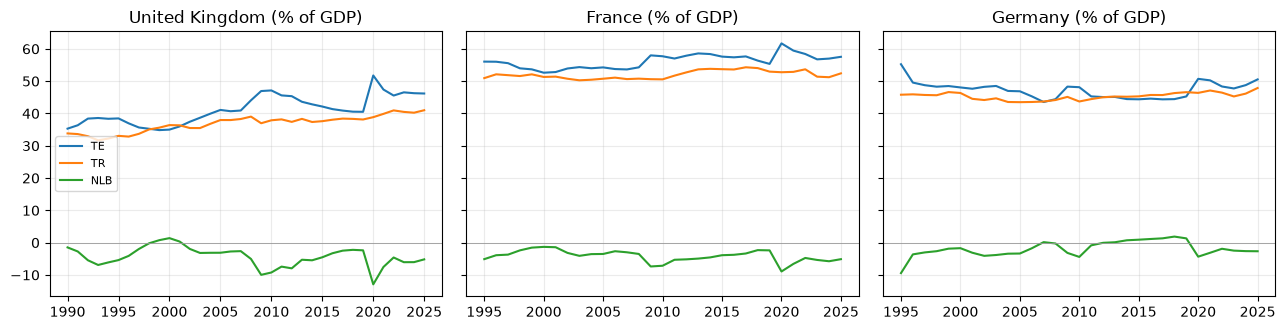

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, iso3 in zip(axes, ("GBR", "FRA", "DEU")):
    g = ledger.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    ax.plot(g.year, g.te_pct_gdp, label="TE")
    ax.plot(g.year, g.tr_pct_gdp, label="TR")
    ax.plot(g.year, g.nlb_pct_gdp, label="NLB")
    ax.axhline(0, lw=0.6, color="0.6")
    ax.set_title(f"{g.country.iloc[0]} (% of GDP)")
    ax.grid(alpha=0.25)
axes[0].legend(loc="center left", fontsize=8)
fig.tight_layout()
plt.show()

## 6. Reconciliation to the IMF WEO

Two files, answering two different questions.

**`weo_levels_bridge.csv` — do the levels agree?** For every overlap year and
every WEO vintage, our TR, TE, NLB, net interest and GDP sit beside the WEO's
GGR, GGX, GGXCNL, GGXCNL−GGXONLB and NGDP, with the gap classified as

* `perimeter` — a stable definitional difference (the UK's public-sector
  perimeter against general government is the standard case),
* `revision` — our anchor is a newer vintage than the WEO's cut-off,
* `unexplained` — neither, which is flagged for review rather than smoothed.

The `forecast_horizon` rows carry the forward net-interest cross-check: our
`GF01_7 − R07` against the WEO's implied net interest at each horizon. A blank
`ni_ours_mn` means one leg has no forecast anywhere — reported as a hole, not
filled.

**`weo_reconciliation.csv` — do the dynamics agree?** Contributions in
percentage points of GDP, in two blocks:

* `block = "history"` decomposes our own realised year-on-year change in
  NLB/GDP into the contribution of each line, with the anchor's own change in
  B.9/GDP alongside as the target it must reproduce.
* `block = "forecast"` decomposes the **WEO's** projected change in NLB/GDP,
  from its base year to each horizon, into what our published forecast lines
  can account for and what they cannot.

In [15]:
latest = sorted(levels.weo_vintage.dropna().unique())[-1]
print("WEO vintages reconciled:", ", ".join(sorted(levels.weo_vintage.dropna().unique())))
print("latest:", latest)

(levels.query("block == 'history' and weo_vintage == @latest and is_base_year")
 [["country", "year", "tr_ours_mn", "tr_weo_mn", "te_ours_mn", "te_weo_mn",
   "nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te", "gap_classification"]])

WEO vintages reconciled: 2025-04, 2025-10, 2026-04
latest: 2026-04


,country,year,tr_ours_mn,tr_weo_mn,te_ours_mn,te_weo_mn,nlb_ours_mn,nlb_weo_mn,gap_nlb_pct_te,gap_classification
126,Germany,2025,2140194.0,2140194.0,2259341.0,2259341.0,-119147.0,-119147.0,0.0000,revision
255,France,2024,1503590.1,1503612.3,1672708.2,1672700.0,-169118.1,-169087.7,-0.0018,revision
397,United Kingdom,2025,1246259.0,1162402.0,1403741.0,1325736.0,-157482.0,-163334.0,0.4169,perimeter


In [16]:
# The size and stability of the level gap, by country: the perimeter wedge.
(levels.query("block == 'history' and weo_vintage == @latest")
 .groupby("country").gap_nlb_pct_te.agg(["mean", "std", "min", "max"])
 .rename(columns={"mean": "mean gap (% of TE)", "std": "sigma"}))

,mean gap (% of TE),sigma,min,max
country,,,,
France,0.002807,0.024054,-0.0107,0.1263
Germany,0.000000,0.000000,0.0000,0.0000
United Kingdom,-0.102664,0.358483,-1.2671,0.4169


### The history decomposition

For each year, the contribution of every line to the change in NLB/GDP. Revenue
contributions enter with a positive sign when revenue rises; expenditure
contributions with a negative sign when spending rises. Three components sit
beside the lines:

* `NLB_CHANGE_SUM` — the change in the **sum-based** balance,
  $\Delta\!\left(\frac{\sum R - \sum E}{\text{GDP}}\right)$. The line
  contributions add to this exactly.
* `ANCHOR_B9_DELTA` — the anchor's own change in B.9/GDP **minus** that
  sum-based change. It is a rounding and vintage wedge, published as its own
  row and never spread across the lines.
* `WEO_GGXCNL_DELTA` — the WEO's own change in GGXCNL/NGDP over the same year.
  This is the history-side reconciliation: our realised dynamics against the
  IMF's.

In [17]:
hist = recon.query("block == 'history' and variant == 'strict'")
wide = hist.pivot_table(index=["iso3", "year"], columns="component",
                        values="contribution_pp", aggfunc="sum")

# 1. the line contributions add to the sum-based change, exactly
lines_sum = (hist.query("component == 'covered_line'")
             .groupby(["iso3", "year"]).contribution_pp.sum())
print("worst |sum of line contributions - NLB_CHANGE_SUM|:      "
      f"{(lines_sum - wide.NLB_CHANGE_SUM).abs().max():.2e} pp of GDP")

# 2. the anchor's own B.9 change differs only by a rounding/vintage wedge
print("largest anchor-vs-sum wedge (ANCHOR_B9_DELTA):          "
      f"{wide.ANCHOR_B9_DELTA.abs().max():.2e} pp of GDP")

# 3. and our realised dynamics against the WEO's, year by year
print("largest gap to the WEO's own change (WEO_GGXCNL_DELTA): "
      f"{(wide.NLB_CHANGE_SUM - wide.WEO_GGXCNL_DELTA).abs().max():.3f} pp of GDP")
wide.tail(6)

worst |sum of line contributions - NLB_CHANGE_SUM|:      1.78e-15 pp of GDP
largest anchor-vs-sum wedge (ANCHOR_B9_DELTA):          3.62e-01 pp of GDP
largest gap to the WEO's own change (WEO_GGXCNL_DELTA): 0.253 pp of GDP


component  ANCHOR_B9_DELTA  NLB_CHANGE_SUM  WEO_GGXCNL_DELTA  covered_line
iso3 year                                                                 
GBR  2019         0.000006       -0.148166         -0.148161     -0.148166
     2020        -0.000130      -10.532435        -10.532565    -10.532435
     2021         0.000214        5.375265          5.375393      5.375265
     2022        -0.000064        2.937620          2.938184      2.937620
     2023        -0.004785       -1.448196         -1.446910     -1.448196
     2024        -0.231105        0.243710         -0.009653      0.243710

In [18]:
# What drove the UK's balance in a single year, largest movers first.
year = int(hist.query("iso3 == 'GBR'").year.max())
drivers = (hist.query("iso3 == 'GBR' and year == @year and "
                      "component == 'covered_line'")
           .sort_values("contribution_pp", key=abs, ascending=False)
           [["side", "line_code", "contribution_pp"]].head(10))
print(f"United Kingdom, change in NLB/GDP in {year}, pp of GDP")
drivers.set_index(["side", "line_code"])

United Kingdom, change in NLB/GDP in 2024, pp of GDP


contribution_pp
side        line_code                 
expenditure GF04              0.925161
            GF10             -0.536046
revenue     R06              -0.402412
expenditure GF01              0.337166
revenue     R03               0.288134
expenditure GF07             -0.184622
revenue     R01              -0.181260
            R02              -0.119117
            R10               0.099030
expenditure GF02             -0.048836

### The forecast decomposition

The question this answers is precise: *of the change in the balance the WEO
projects, how much can be accounted for by the official, line-level forecasts
we were able to publish?*

The components:

* `weo_change` — the WEO's own projected change in NLB/GDP from its base year.
  This is the quantity being explained.
* `covered_line` / `covered_total` — what our published forecast lines
  contribute.
* `denom_effect` — the effect of the GDP denominator path.
* `resid_coverage` — the part attributable to lines nobody forecasts. A hole in
  coverage, reported as such.
* `resid_disagreement` — the part where our covered lines move differently from
  the WEO aggregate.
* `resid_total` — the two together, where the data do not allow them to be
  split.
* `explained_share` — covered contributions as a share of `weo_change`. 1.0
  means the official granular forecasts fully account for the WEO's projected
  move.

Residuals are **reported, never allocated**. A low explained share is a finding
about the availability of official forecasts, not a defect to be patched.

In [19]:
shares = (recon.query("block == 'forecast' and component == 'explained_share' "
                      "and weo_vintage == @latest")
          .pivot_table(index=["country", "variant"], columns="year",
                       values="contribution_pp"))
shares.round(2)

year                              2025  2026  2027  2028  2029  2030  2031
country        variant                                                    
France         maximum_extension  0.11 -2.13 -2.70 -0.35 -0.16 -0.07 -0.02
               strict             1.13  0.13  0.16 -0.05  0.00  0.03  0.05
Germany        maximum_extension   NaN  0.50  0.42  0.49  0.43  0.38  0.56
               strict              NaN -0.00 -0.20  0.17  0.08 -0.08 -0.13
United Kingdom maximum_extension   NaN  0.60  0.76  0.68  0.71  0.75  0.00
               strict              NaN  0.59  0.67  0.55  0.56  0.58  0.00

In [20]:
# One country, one horizon, in full: the components that add up to the
# WEO's projected change.
iso3, variant = "GBR", "strict"
horizon = int(recon.query("block == 'forecast' and iso3 == @iso3 and "
                          "weo_vintage == @latest and "
                          "component == 'weo_change'").year.min())
cut = recon.query("block == 'forecast' and iso3 == @iso3 and "
                  "variant == @variant and weo_vintage == @latest and "
                  "year == @horizon")
summary = (cut[cut.component.isin(["weo_change", "covered_total", "denom_effect",
                                   "resid_coverage", "resid_disagreement",
                                   "resid_total"])]
           [["side", "component", "contribution_pp", "component_meaning"]])
print(f"{iso3} {variant}, WEO {latest}, change in NLB/GDP to {horizon} "
      "(pp of GDP)")
summary.set_index(["side", "component"])

GBR strict, WEO 2026-04, change in NLB/GDP to 2026 (pp of GDP)


contribution_pp                                  component_meaning
side        component                                                                             
balance     covered_total              0.868904  sum of the covered-line contributions on that ...
            weo_change                 1.472374  the WEO's own change in NLB/GDP over the same ...
expenditure denom_effect               0.003729    effect of the GDP denominator path on the ratio
            resid_coverage            -0.473227  part of the change attributable to lines with ...
            resid_disagreement         0.284442  part attributable to covered lines moving diff...
revenue     denom_effect              -0.086802    effect of the GDP denominator path on the ratio
            resid_coverage             0.352845  part of the change attributable to lines with ...
            resid_disagreement         0.522482  part attributable to covered lines moving diff...

In [21]:
# The covered lines behind that total, largest first.
(cut.query("component == 'covered_line'")
 .sort_values("contribution_pp", key=abs, ascending=False)
 [["side", "line_code", "contribution_pp"]].head(12)
 .set_index(["side", "line_code"]))

contribution_pp
side        line_code                 
revenue     R03               0.536866
            R02               0.243879
            R01               0.066458
            R06               0.059708
expenditure GF02             -0.026859
revenue     R04              -0.011146

## 7. Limits worth knowing before you use the numbers

* **Do not mix variants inside one series.** `strict` and `maximum_extension`
  are separate constructions; the catalogue's `final_strict_year` and
  `final_maximum_year` tell you where each stops.
* **Grades C and D are proxies.** They are published because a measured proxy
  with a declared residual assumption beats a blank column, not because they
  are as good as an outturn. `coverage_share` says how much of the line the
  proxy actually covers.
* **The UK sits on a different perimeter.** UK fiscal aggregates are published
  on a public-sector basis; the level bridge measures that wedge against the
  WEO's general-government aggregates and shows it to be small and stable, but
  it is not zero.
* **`GF01_7` is D.41 where COFOG Level II is missing.** Gross interest payable
  from the same institution, flagged on every affected row — the same accrued
  gross concept, but not literally the COFOG 01.7 cell.
* **Pre-1995 expenditure is thin.** COFOG detail simply was not compiled on the
  current basis before then for most functions; the revenue side reaches much
  further back.
* **A low explained share is information.** For the forecast horizons where
  little of the WEO's projected consolidation is accounted for, the reason is
  that no official body publishes line-level forecasts covering it.

Every one of these is visible in the files themselves — in `quality_grade`,
`coverage_share`, `gap_classification`, `notes` and `reason_series_ends` —
rather than only in this notebook.

In [22]:
# Where to look things up.
dictionary.groupby("file").size().rename("documented columns").to_frame()

,documented columns
file,
balance_ledger.csv,22
data_dictionary.csv,3
expenditure_cofog.csv,26
revenue_esa.csv,26
series_catalogue.csv,23
weo_levels_bridge.csv,32
weo_reconciliation.csv,14
